In [7]:
%pip install --break-system-packages pandas matplotlib seaborn fastparquet

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 5.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 15.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.5/202.5 kB 7.6 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


# F1 Race Results Data Exploration

This notebook explores the combined F1 race results data from 2018-2020.

In [27]:
# Load the combined dataset
df = pd.read_parquet('../data/processed/race_results_combined.parquet', engine='fastparquet')

In [28]:
# Display first few rows
df.head()

,DriverNumber,BroadcastName,Abbreviation,DriverId,TeamName,TeamColor,TeamId,FirstName,LastName,FullName,...,Q1,Q2,Q3,Time,Status,Points,Laps,Season,Round,RaceName
0,5,S VETTEL,VET,vettel,Ferrari,DC0000,ferrari,Sebastian,Vettel,Sebastian Vettel,...,NaN,NaN,NaN,5.373283e+12,Finished,25.0,58.0,2018,1,Australian Grand Prix
1,44,L HAMILTON,HAM,hamilton,Mercedes,00D2BE,mercedes,Lewis,Hamilton,Lewis Hamilton,...,NaN,NaN,NaN,5.036000e+09,Finished,18.0,58.0,2018,1,Australian Grand Prix
2,7,K RAIKKONEN,RAI,raikkonen,Ferrari,DC0000,ferrari,Kimi,Räikkönen,Kimi Räikkönen,...,NaN,NaN,NaN,6.309000e+09,Finished,15.0,58.0,2018,1,Australian Grand Prix
3,3,D RICCIARDO,RIC,ricciardo,Red Bull Racing,1E41FF,red_bull,Daniel,Ricciardo,Daniel Ricciardo,...,NaN,NaN,NaN,7.069000e+09,Finished,12.0,58.0,2018,1,Australian Grand Prix
4,14,F ALONSO,ALO,alonso,McLaren,FF8700,mclaren,Fernando,Alonso,Fernando Alonso,...,NaN,NaN,NaN,2.788600e+10,Finished,10.0,58.0,2018,1,Australian Grand Prix


In [29]:
# Basic statistics
df.describe()

,Position,GridPosition,Q1,Q2,Q3,Time,Points,Laps,Season,Round
count,2976.000000,2976.00000,0.0,0.0,0.0,1.874000e+03,2979.000000,2979.000000,2979.000000,2979.000000
mean,10.487231,10.22547,NaN,NaN,NaN,4.959196e+11,5.072675,54.520980,2021.106412,11.237664
std,5.760588,5.80396,NaN,NaN,NaN,1.580581e+12,7.221712,17.356738,2.030432,6.284815
min,1.000000,0.00000,NaN,NaN,NaN,1.790000e+08,0.000000,0.000000,2018.000000,1.000000
25%,5.000000,5.00000,NaN,NaN,NaN,1.825250e+10,0.000000,51.000000,2019.000000,6.000000
50%,10.000000,10.00000,NaN,NaN,NaN,4.219050e+10,0.500000,56.000000,2021.000000,11.000000
75%,15.000000,15.00000,NaN,NaN,NaN,7.030250e+10,9.000000,67.000000,2023.000000,16.000000
max,20.000000,20.00000,NaN,NaN,NaN,1.090400e+13,26.000000,87.000000,2024.000000,24.000000


In [30]:
# Check for missing values
df.isnull().sum()

DriverNumber             0
BroadcastName            3
Abbreviation             0
DriverId                 0
TeamName                 0
TeamColor                3
TeamId                   0
FirstName                0
LastName                 0
FullName                 0
HeadshotUrl             61
CountryCode              2
Position                 3
ClassifiedPosition       0
GridPosition             3
Q1                    2979
Q2                    2979
Q3                    2979
Time                  1105
Status                   0
Points                   0
Laps                     0
Season                   0
Round                    0
RaceName                 0
dtype: int64

Season
2018    21
2019    21
2020    17
2021    22
2022    22
2023    22
2024    24
Name: RaceName, dtype: int64


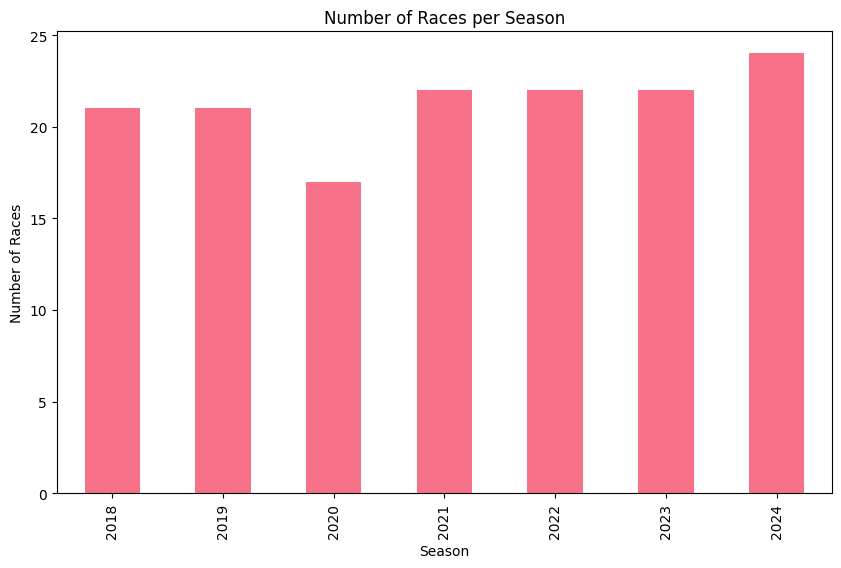

In [31]:
# Races per season
races_per_season = df.groupby('Season')['RaceName'].nunique()
print(races_per_season)

races_per_season.plot(kind='bar', figsize=(10, 6))
plt.title('Number of Races per Season')
plt.xlabel('Season')
plt.ylabel('Number of Races')
plt.show()

Top 10 Drivers by Total Points (2018-2020):
FullName
Max Verstappen      2491.5
Lewis Hamilton      2210.5
Charles Leclerc     1363.0
Sergio Perez        1118.0
Carlos Sainz        1085.5
Valtteri Bottas     1072.0
Lando Norris         950.0
Sebastian Vettel     673.0
George Russell       664.0
Daniel Ricciardo     504.0
Name: Points, dtype: float64


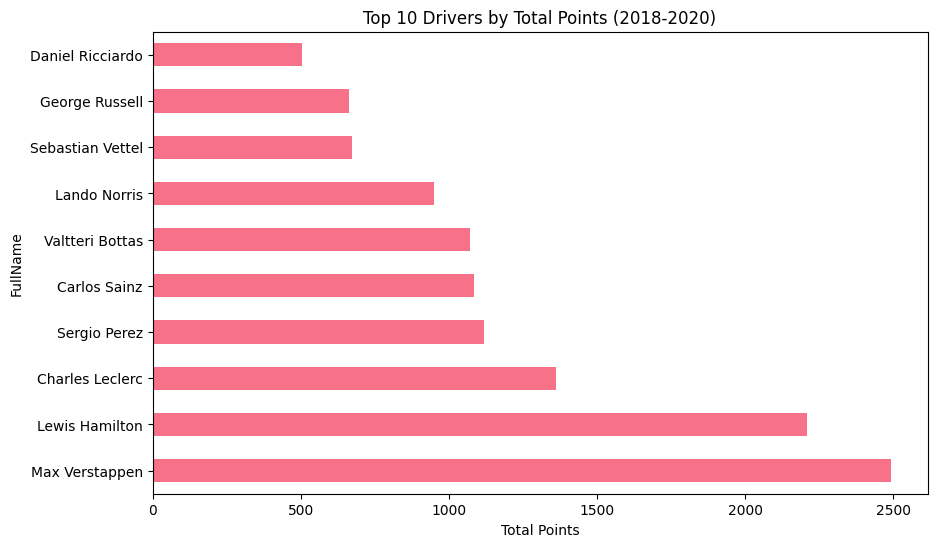

In [32]:
# Top drivers by points
driver_points = df.groupby(['FullName', 'Season'])['Points'].sum().reset_index()
top_drivers = driver_points.groupby('FullName')['Points'].sum().nlargest(10)

print("Top 10 Drivers by Total Points (2018-2020):")
print(top_drivers)

top_drivers.plot(kind='barh', figsize=(10, 6))
plt.title('Top 10 Drivers by Total Points (2018-2020)')
plt.xlabel('Total Points')
plt.show()

Top 10 Constructors by Total Points (2018-2024):
TeamName
Mercedes           3873.5
Red Bull Racing    3784.5
Ferrari            3005.5
McLaren            1708.0
Alpine              498.0
Aston Martin        492.0
Renault             394.0
Racing Point        335.0
AlphaTauri          306.0
Haas F1 Team        217.0
Name: Points, dtype: float64


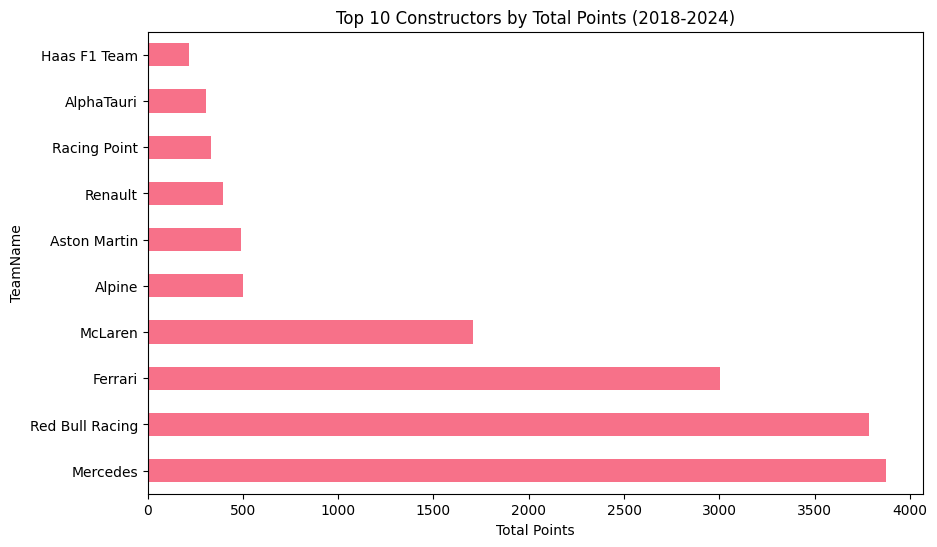

In [35]:
# Constructor (team) performance
constructor_points = df.groupby(['TeamName', 'Season'])['Points'].sum().reset_index()
top_constructors = constructor_points.groupby('TeamName')['Points'].sum().nlargest(10)

print("Top 10 Constructors by Total Points (2018-2024):")
print(top_constructors)

top_constructors.plot(kind='barh', figsize=(10, 6))
plt.title('Top 10 Constructors by Total Points (2018-2024)')
plt.xlabel('Total Points')
plt.show()

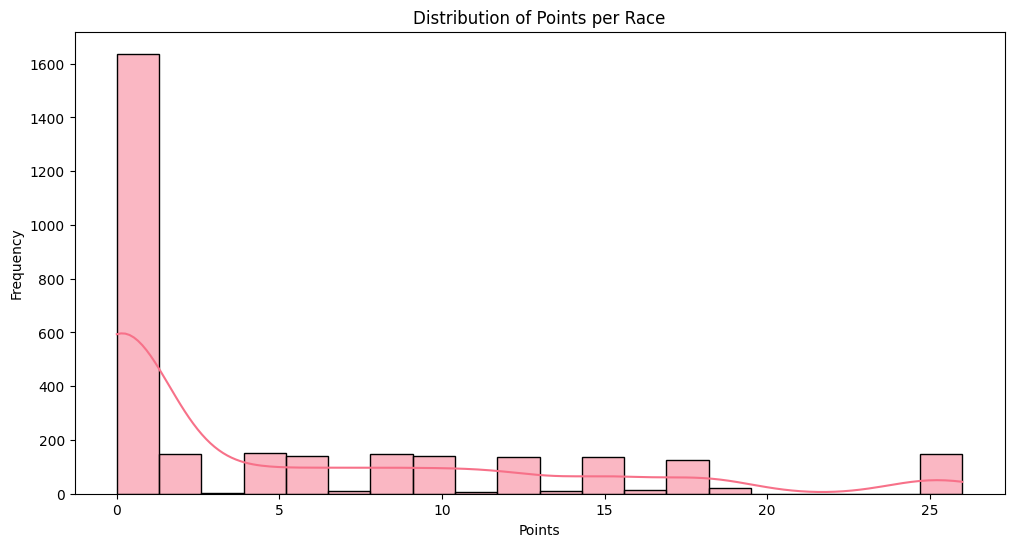

In [36]:
# Points distribution
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='Points', bins=20, kde=True)
plt.title('Distribution of Points per Race')
plt.xlabel('Points')
plt.ylabel('Frequency')
plt.show()

Race Winners (2018-2020):
FullName
Max Verstappen      60
Lewis Hamilton      43
Charles Leclerc      8
Valtteri Bottas      7
Sebastian Vettel     6
Sergio Perez         6
Carlos Sainz         4
Lando Norris         4
Daniel Ricciardo     3
George Russell       3
Name: count, dtype: int64


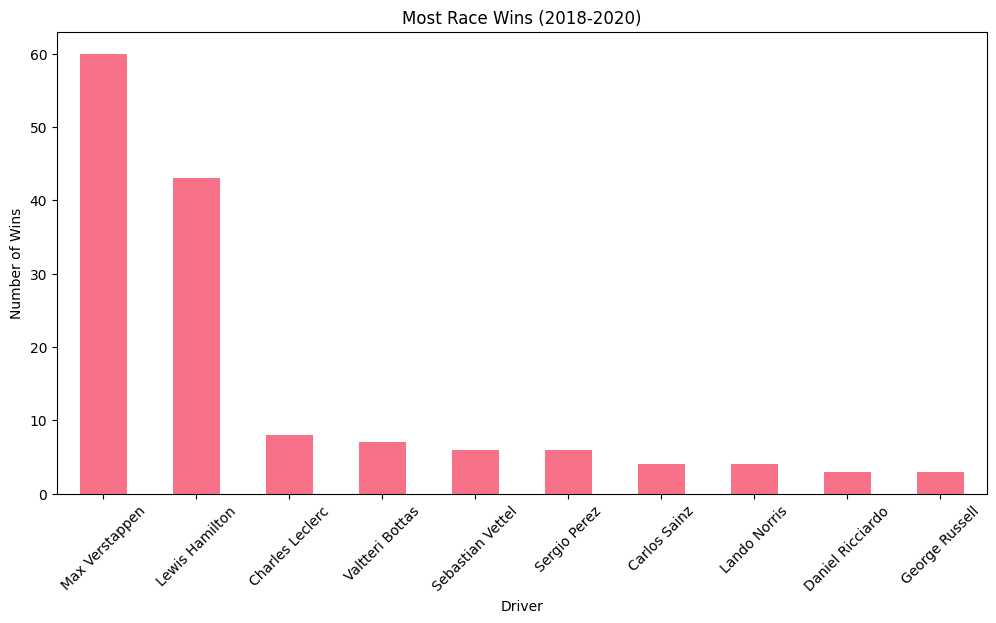

In [37]:
# Race winners
winners = df[df['Position'] == 1].copy()
winner_counts = winners['FullName'].value_counts()

print("Race Winners (2018-2020):")
print(winner_counts.head(10))

winner_counts.head(10).plot(kind='bar', figsize=(12, 6))
plt.title('Most Race Wins (2018-2020)')
plt.xlabel('Driver')
plt.ylabel('Number of Wins')
plt.xticks(rotation=45)
plt.show()